In [1]:
from dotenv import load_dotenv
from langchain_openai import AzureChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os 

load_dotenv()
azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
api_key = os.getenv("AZURE_OPENAI_API_KEY")
api_version = os.getenv("AZURE_OPENAI_API_VERSION")
deployment_name = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")



chat_model = AzureChatOpenAI(azure_endpoint=azure_endpoint,
    api_key=api_key,
    api_version=api_version,
    deployment_name=deployment_name)

c:\Users\HarshVardhanSingh\anaconda3\envs\demo_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Example 1 

In [3]:
# Simple one-line prompt
prompt = PromptTemplate.from_template("{question}")
parser = StrOutputParser()

# Chain: prompt → model → parser
chain = prompt | chat_model | parser

# Run it
result = chain.invoke({"question": "Who is stephen curry?"})
print(result)

Stephen Curry is a professional basketball player from the United States, widely regarded as one of the greatest shooters in NBA history. He was born on March 14, 1988, in Akron, Ohio, but he grew up in Charlotte, North Carolina. Curry played college basketball at Davidson College, where he gained national attention for leading his team to the NCAA Tournament's Elite Eight in 2008.

He was selected by the Golden State Warriors as the seventh overall pick in the 2009 NBA Draft. Since then, Curry has become synonymous with the Warriors' success, leading the team to multiple NBA championships. He is known for his exceptional shooting ability, particularly from three-point range, which has significantly changed the style of play in the NBA.

Curry is also a two-time NBA Most Valuable Player (MVP) and has been selected to numerous All-Star teams. His work ethic, leadership, and skill have made him a role model for many young athletes. Off the court, he is involved in various philanthropic e

### Example 2

In [15]:
prompt1 = PromptTemplate(
    template='Generate a detailed report on {topic}',
    input_variables=['topic']
)

prompt2 = PromptTemplate(
    template='Generate a 5 pointer summary from the following text \n {text}',
    input_variables=['text']
)


parser = StrOutputParser()

# Step 1
report = (prompt1 | chat_model).invoke({'topic': 'Unemployment in India'})

# Step 2
summary = (prompt2 | chat_model).invoke({'text': report.content})


def get_usage(response):
    usage = response.response_metadata.get("token_usage", {})
    return (
        usage.get("prompt_tokens", 0),
        usage.get("completion_tokens", 0)
    )

p1, c1 = get_usage(report)
p2, c2 = get_usage(summary)

total_prompt = p1 + p2
total_completion = c1 + c2


PRICING = {
    "input": 0.00000015,   # per token
    "output": 0.0000006
}

cost = (
    total_prompt * PRICING["input"] +
    total_completion * PRICING["output"]
)

print(f"Total Cost: ${cost}")

Total Cost: $0.0008568


1263

In [7]:
type(result)

langchain_core.messages.base.TextAccessor

In [8]:
chat_model

AzureChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x0000016D0787D4B0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000016D07E61A50>, root_client=<openai.lib.azure.AzureOpenAI object at 0x0000016D0787CF40>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x0000016D0787D210>, model_kwargs={}, openai_api_key=SecretStr('**********'), disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://demodsopenai.openai.azure.com/', deployment_name='testgpt4omini', openai_api_version='2025-01-01-preview', openai_api_type='azure')

In [9]:
chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='Generate a detailed report on {topic}')
| AzureChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x0000016D0787D4B0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000016D07E61A50>, root_client=<openai.lib.azure.AzureOpenAI object at 0x0000016D0787CF40>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x0000016D0787D210>, model_kwargs={}, openai_api_key=SecretStr('**********'), disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://demodsopenai.openai.azure.com/', deployment_name='testgpt4omini', openai_api_version='2025-01-01-preview', openai_api_type='azure')
| StrOutputParser()
| PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='Generate a 5 pointer summary from the following text \n {text}')
| AzureChatOpenAI(client=<openai.resources.chat.comple

### Example - 3 Langsmith RAG

In [19]:
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import AzureOpenAIEmbeddings, AzureChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser


PDF_PATH = "StatsRefSample.pdf"  # <-- change to your PDF filename

# 1) Load PDF
loader = PyPDFLoader(PDF_PATH)
docs = loader.load()  # one Document per page

# 2) Chunk
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
splits = splitter.split_documents(docs)

# 3) Embed + index
emb = AzureOpenAIEmbeddings(model="text-embedding-3-large",
                            azure_endpoint=azure_endpoint,
                            api_key=api_key,
                            api_version=api_version)

vs = FAISS.from_documents(splits, emb)
retriever = vs.as_retriever(search_type="similarity", search_kwargs={"k": 4})

# 4) Prompt
prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer ONLY from the provided context. If not found, say you don't know."),
    ("human", "Question: {question}\n\nContext:\n{context}")
])

# 5) Chain
llm = AzureChatOpenAI(azure_endpoint=azure_endpoint,
    api_key=api_key,
    api_version=api_version,
    deployment_name=deployment_name)

def format_docs(docs): return "\n\n".join(d.page_content for d in docs)

parallel = RunnableParallel({
    "context": retriever | RunnableLambda(format_docs),
    "question": RunnablePassthrough()
})

chain = parallel | prompt | llm | StrOutputParser()

# 6) Ask questions
print("PDF RAG ready. Ask a question (or Ctrl+C to exit).")
q = input("\nQ: ")
ans = chain.invoke(q.strip())
print("\nA:", ans)

PDF RAG ready. Ask a question (or Ctrl+C to exit).

A: I don't know.


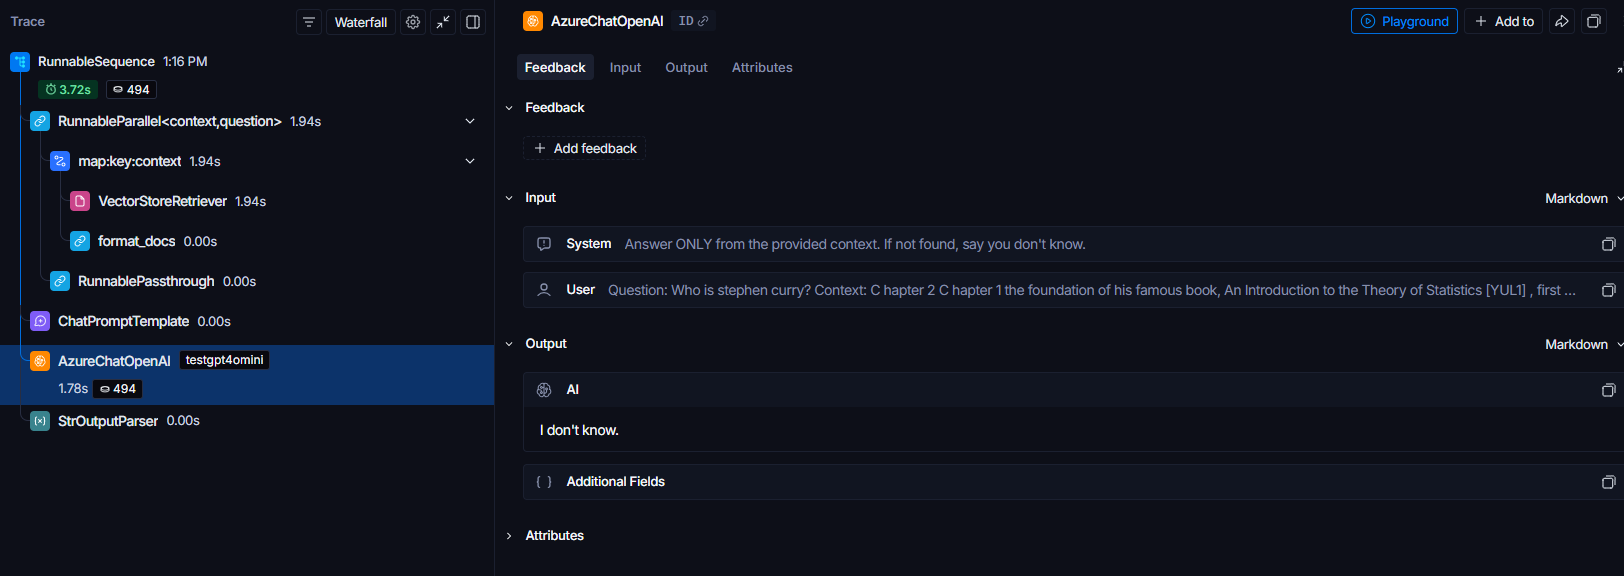